# Classificação Supervisionada com Agglomerative Clustering no Dataset Dry Bean (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Dry Bean com balanceamento das classes via oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import os
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Dry Bean é carregado e as classes minoritárias são balanceadas por oversampling, igualando a quantidade de exemplos de todas as classes. Isso evita que o modelo favoreça as classes majoritárias.

In [2]:
# Carregar o dataset Dry Bean
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

# Exibe distribuição original das classes
print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Exibe distribuição após balanceamento
print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [3]:
# Codificar variáveis categóricas
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))

# Separar features e alvo
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Dendrograma)

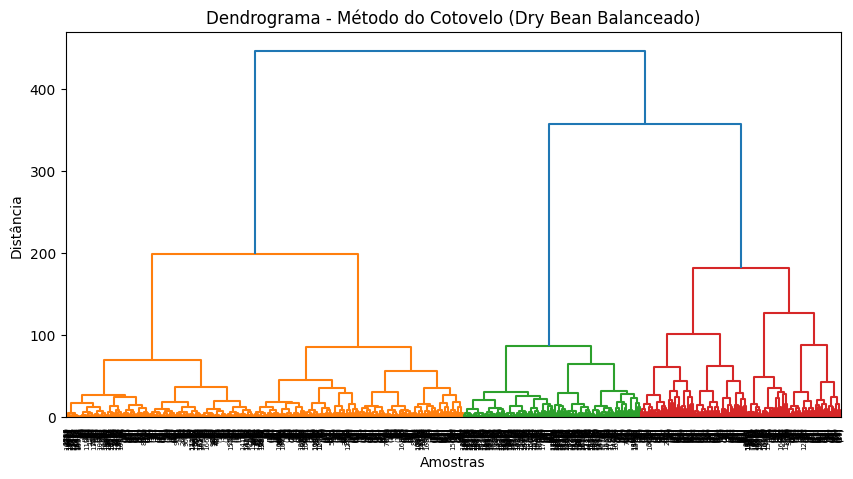

In [5]:
plt.figure(figsize=(10, 5))
linked = linkage(X_train, method='ward')
dendrogram(linked, truncate_mode='level', p=10)
plt.title('Dendrograma - Método do Cotovelo (Dry Bean Balanceado)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.savefig('img/agglo_drybean_balance_dendrogram.png')
plt.show()
# Sugestão: escolha visual do número de clusters (exemplo: 7)

## 6. Implementação do Classificador Agglomerative Supervisionado

In [6]:
class AggloSupervisionado:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.7963
Matriz de Confusão:
[[ 950    0   68    0    6   11   28]
 [   0 1064    0    0    0    0    0]
 [  66    0  913    0   69    0   16]
 [   8    0    0    0    1   23 1032]
 [   6    0   27    0 1010    0   21]
 [  10    0    0    0    0  980   74]
 [  14    0   10    0   21    6 1013]]


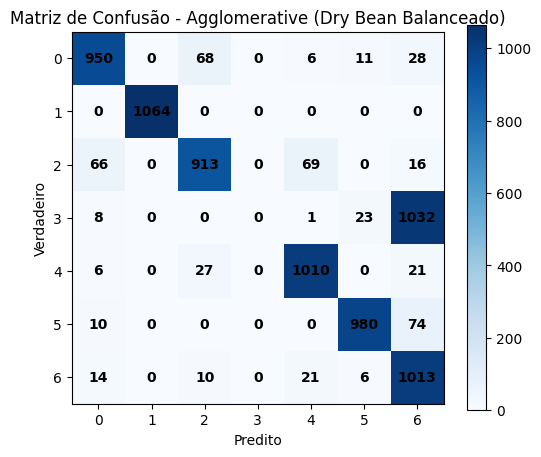

In [7]:
n_clusters = 7  # Ajuste conforme o dendrograma
clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Agglomerative (Dry Bean Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
# Adiciona os valores nas células
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/agglo_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

Acurácia média: 0.4788
Desvio padrão da acurácia: 0.2106
MSE médio: 3.1630
Desvio padrão do MSE: 2.5417


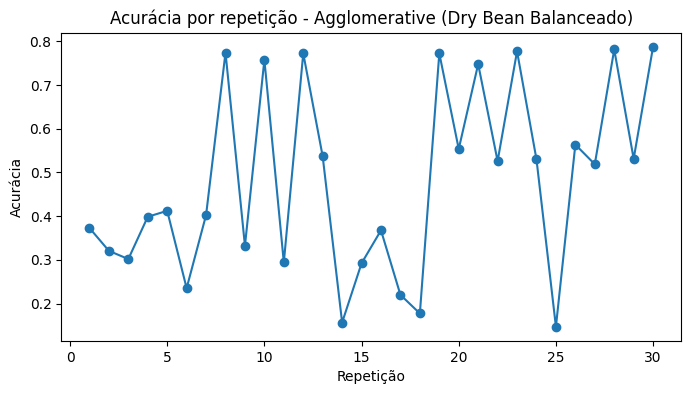

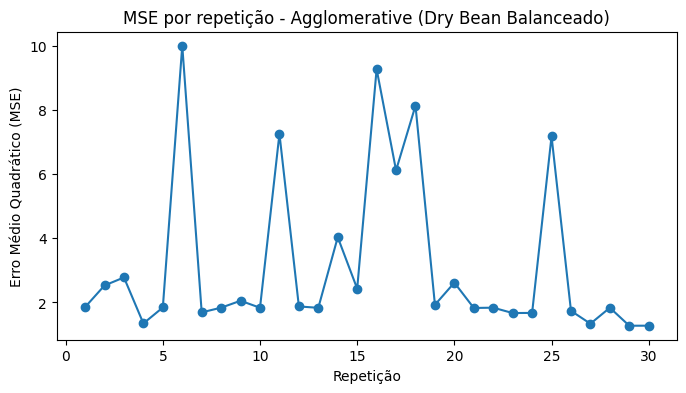

In [8]:
acuracias = []
mse_list = []
from sklearn.metrics import mean_squared_error
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Dry Bean Balanceado)')
plt.savefig('img/agglo_drybean_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Agglomerative (Dry Bean Balanceado)')
plt.savefig('img/agglo_drybean_balance_mse_repetitions.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/agglo_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/agglo_drybean_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/agglo_drybean_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/agglo_drybean_balance_mse_repetitions.csv', mse_array, delimiter=',')

## 9. Cálculo das Principais Métricas de Avaliação

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calcular_metricas_multiclasse(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade média: média das especificidades de cada classe
    especificidades = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        especificidades.append(especificidade)
    especificidade_media = np.mean(especificidades)
    return acc, prec, rec, especificidade_media, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas_multiclasse(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))